### MOFA

### Data extraction

In [1]:
#import library
import os
import sys 

NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
sys.path.insert(0, PROJECT_ROOT)

import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from palettable import wesanderson as wes
from implementations_MOFA import*
from utility import*

In [2]:
#Load all omics and their metadatas
data_dir = "./../data/TCGA-BRCA/"
mod = ["mRNA", "DNAm" , "RPPA"]

data = {}
for omic in mod : 
 with open(f"{data_dir}{omic}.pkl", "rb") as f:  # 'rb' = read binary
    data[omic] = pickle.load(f) 
    
mRNA_expr = data['mRNA']['expr']
mRNA_meta = data['mRNA']['meta']
DNAm_expr = data['DNAm']['expr']
DNAm_meta = data['DNAm']['meta']
RPPA_expr = data['RPPA']['expr']
RPPA_meta = data['RPPA']['meta']

In [3]:
# Put together meta data off patients from all omics
df_all_meta = pd.concat([mRNA_meta,DNAm_meta,RPPA_meta], ignore_index=False)
df_all_meta = df_all_meta.drop_duplicates(subset="patient")

#, one hot encoding of tumour subtypes
onehot = pd.get_dummies(df_all_meta["paper_BRCA_Subtype_PAM50"])
df_all_meta = pd.concat([df_all_meta, onehot[['LumA', 'LumB', 'Basal', 'Her2']]], axis=1)

# save meta data
df_all_meta.to_csv('all_meta.csv', index=False)

In [4]:
df_all_meta

,patient,race,gender,sample_type,paper_BRCA_Subtype_PAM50,sizeFactor,replaceable,LumA,LumB,Basal,Her2
TCGA-E9-A228,TCGA-E9-A228,white,female,Primary Tumor,LumB,1.329814,True,False,True,False,False
TCGA-HN-A2NL,TCGA-HN-A2NL,not reported,female,Primary Tumor,Basal,1.129338,True,False,False,True,False
TCGA-OL-A5D7,TCGA-OL-A5D7,black or african american,female,Primary Tumor,Basal,0.727540,True,False,False,True,False
TCGA-A2-A3KC,TCGA-A2-A3KC,black or african american,female,Primary Tumor,LumA,1.100696,True,True,False,False,False
TCGA-A2-A0YI,TCGA-A2-A0YI,white,female,Primary Tumor,LumA,1.296389,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
TCGA-S3-AA0Z,TCGA-S3-AA0Z,black or african american,female,Primary Tumor,Basal,NaN,NaN,False,False,True,False
TCGA-BH-A0BW,TCGA-BH-A0BW,black or african american,female,Primary Tumor,Basal,NaN,NaN,False,False,True,False
TCGA-E2-A15G,TCGA-E2-A15G,white,female,Primary Tumor,LumA,NaN,NaN,True,False,False,False
TCGA-BH-A0EB,TCGA-BH-A0EB,white,female,Primary Tumor,LumA,NaN,NaN,True,False,False,False


###  Stratified split of patients in 5 group/folds of similar size and proportions of each tumour subtype

In [5]:
folds = create_stratified_folds(
    df_all_meta,
    stratify_col="paper_BRCA_Subtype_PAM50"
)

Fold 1 (size=132):
paper_BRCA_Subtype_PAM50
LumA     0.530303
LumB     0.212121
Basal    0.181818
Her2     0.075758
Name: proportion, dtype: float64
----------------------------------------
Fold 2 (size=132):
paper_BRCA_Subtype_PAM50
LumA     0.530303
LumB     0.212121
Basal    0.181818
Her2     0.075758
Name: proportion, dtype: float64
----------------------------------------
Fold 3 (size=132):
paper_BRCA_Subtype_PAM50
LumA     0.537879
LumB     0.212121
Basal    0.174242
Her2     0.075758
Name: proportion, dtype: float64
----------------------------------------
Fold 4 (size=131):
paper_BRCA_Subtype_PAM50
LumA     0.541985
LumB     0.206107
Basal    0.183206
Her2     0.068702
Name: proportion, dtype: float64
----------------------------------------
Fold 5 (size=131):
paper_BRCA_Subtype_PAM50
LumA     0.534351
LumB     0.206107
Basal    0.183206
Her2     0.076336
Name: proportion, dtype: float64
----------------------------------------


In [6]:
folds[0].head(4)

,patient,race,gender,sample_type,paper_BRCA_Subtype_PAM50,sizeFactor,replaceable,LumA,LumB,Basal,Her2
TCGA-OL-A5D7,TCGA-OL-A5D7,black or african american,female,Primary Tumor,Basal,0.727540,True,False,False,True,False
TCGA-AC-A23C,TCGA-AC-A23C,white,female,Primary Tumor,LumA,1.388409,True,True,False,False,False
TCGA-A7-A4SA,TCGA-A7-A4SA,white,female,Primary Tumor,LumA,0.708618,True,True,False,False,False
TCGA-D8-A73W,TCGA-D8-A73W,white,female,Primary Tumor,LumA,0.893747,True,True,False,False,False


### Split the omic datasets based on patient IDs

In [7]:
mRNA_exprs, DNAm_exprs, RPPA_exprs, all_metas = create_subsets_from_fold(df_all_meta,mRNA_expr, DNAm_expr, RPPA_expr,folds)

In [9]:
all_metas[0].head(3)

,patient,race,gender,sample_type,paper_BRCA_Subtype_PAM50,sizeFactor,replaceable,LumA,LumB,Basal,Her2
TCGA-OL-A5D7,TCGA-OL-A5D7,black or african american,female,Primary Tumor,Basal,0.727540,True,False,False,True,False
TCGA-AC-A23C,TCGA-AC-A23C,white,female,Primary Tumor,LumA,1.388409,True,True,False,False,False
TCGA-A7-A4SA,TCGA-A7-A4SA,white,female,Primary Tumor,LumA,0.708618,True,True,False,False,False


In [10]:
mRNA_exprs[0].head(3)

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288611.1,ENSG00000288612.1,ENSG00000288638.1,ENSG00000288648.1,ENSG00000288657.1,ENSG00000288658.1,ENSG00000288663.1,ENSG00000288670.1,ENSG00000288674.1,ENSG00000288675.1
TCGA-OL-A5D7,11.436488,4.204181,11.338812,10.696614,11.024408,9.917112,9.852083,10.494274,10.290863,12.049691,...,3.469872,6.238882,2.843467,2.843467,2.843467,5.977719,5.808513,9.188112,4.707533,6.365531
TCGA-AC-A23C,9.078849,6.572918,12.069337,11.142150,9.607170,8.432626,11.703024,11.683570,10.684474,11.632446,...,3.298594,5.687293,2.843467,2.843467,2.843467,6.777134,5.824274,9.122388,4.466509,5.138319
TCGA-A7-A4SA,11.785303,6.683121,11.496328,10.592513,9.566031,9.248839,11.148112,11.696691,11.314829,10.589873,...,3.733952,6.216133,2.843467,2.843467,2.843467,5.419066,5.602120,7.931737,4.729262,4.809459


In [11]:
DNAm_exprs[0].head(3)

,cg11738485,cg01893212,cg21885317,cg12466610,cg15690342,cg22473620,cg02467990,cg23179456,cg04131969,cg22831607,...,cg00592510,cg06459913,cg01749500,cg17985854,cg16023912,cg03407594,cg07290865,cg06153893,cg10262891,cg07132590
TCGA-OL-A5D7,0.021655,0.035954,0.979647,0.828104,0.124674,0.072108,0.031360,0.025608,0.927734,0.731654,...,0.080530,0.945476,0.681666,0.447804,0.832570,0.843092,0.911593,0.045209,0.614898,0.951736
TCGA-AC-A23C,0.595519,0.672405,0.403244,0.063852,0.393983,0.522217,0.612764,0.628289,0.958121,0.652212,...,0.146034,0.895260,0.656652,0.430810,0.714198,0.712563,0.733808,0.102438,0.745312,0.950630
TCGA-A7-A4SA,0.978297,0.047852,0.838459,0.062697,0.692043,0.620420,0.041754,0.225888,0.368481,0.059167,...,0.107216,0.919907,0.706555,0.421245,0.773050,0.578687,0.873874,0.045488,0.557427,0.820625


In [12]:
RPPA_exprs[0].head(3)

,1433BETA,1433EPSILON,1433ZETA,4EBP1,4EBP1_pS65,4EBP1_pT37T46,4EBP1_pT70,53BP1,ACC_pS79,ACC1,...,XPF,XRCC1,YAP,YAP_pS127,YB1,YB1_pS102,YTHDF2,YTHDF3,ZAP-70,ZEB1
TCGA-OL-A5D7,-0.014454,0.026866,-0.334580,0.67399,-0.60553,-0.491210,-0.009052,-0.38494,-0.186570,-0.561320,...,0.100363,0.10002,-0.020238,-0.605830,-0.67684,-0.154990,0.508370,-0.157935,2.031538,0.245044
TCGA-AC-A23C,0.574640,-0.426730,0.098341,-0.90781,-0.38016,0.434590,-0.439650,-0.37830,0.023003,-0.038222,...,0.252477,-0.51522,-0.063515,0.068287,0.11098,-0.096815,0.141395,-0.371630,1.084743,0.279058
TCGA-A7-A4SA,0.240770,0.030830,0.132490,-0.44458,-0.77960,0.057376,-0.137430,-0.70126,0.614250,0.303330,...,0.067078,-0.20323,0.090495,-0.125980,-0.59031,0.008033,-0.337855,-0.582240,1.223723,0.355089


#### MOFA_format function converts a DataFrame representing omics expression matrices (rows = samples, columns = features) into an optimized long-format DataFrame compatible with MOFA, where each row corresponds to a view — a single cell from an omics expression matrix.

In [13]:
#Example of output
example = MOFA_format(RPPA_exprs[0],'RPPA')
example.head(10)

,sample,view,feature,value
0,TCGA-OL-A5D7,RPPA,1433BETA,-0.014454
1,TCGA-AC-A23C,RPPA,1433BETA,0.574640
2,TCGA-A7-A4SA,RPPA,1433BETA,0.240770
3,TCGA-D8-A73W,RPPA,1433BETA,0.007712
4,TCGA-AR-A1AW,RPPA,1433BETA,0.175435
5,TCGA-D8-A1XZ,RPPA,1433BETA,-0.054489
6,TCGA-BH-A8FY,RPPA,1433BETA,-0.254920
7,TCGA-BH-A1ES,RPPA,1433BETA,0.466515
8,TCGA-BH-A201,RPPA,1433BETA,0.471220
9,TCGA-E2-A1B1,RPPA,1433BETA,0.286235


In [14]:
example.loc[example['sample'] == 'TCGA-OL-A5D7'].head(10)

,sample,view,feature,value
0,TCGA-OL-A5D7,RPPA,1433BETA,-0.014454
101,TCGA-OL-A5D7,RPPA,1433EPSILON,0.026866
202,TCGA-OL-A5D7,RPPA,1433ZETA,-0.334580
303,TCGA-OL-A5D7,RPPA,4EBP1,0.673990
404,TCGA-OL-A5D7,RPPA,4EBP1_pS65,-0.605530
505,TCGA-OL-A5D7,RPPA,4EBP1_pT37T46,-0.491210
606,TCGA-OL-A5D7,RPPA,4EBP1_pT70,-0.009052
707,TCGA-OL-A5D7,RPPA,53BP1,-0.384940
808,TCGA-OL-A5D7,RPPA,ACC_pS79,-0.186570
909,TCGA-OL-A5D7,RPPA,ACC1,-0.561320


### Train K MOFA models, one per fold/test set, where the remaining folds are used for training.

In [15]:
build_k_MOFA_models(mRNA_exprs, DNAm_exprs, RPPA_exprs)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        

No "group" column found in the data frame, we will assume a common group for all samples...


Loaded group='single_group' view='DNAm' with N=403 samples and D=2000 features...
Loaded group='single_group' view='RPPA' with N=399 samples and D=464 features...
Loaded group='single_group' view='mRNA' with N=403 samples and D=2000 features...


Model options:
- Automatic Relevance De

Iteration 79: time=1.80, ELBO=-1357144.85, deltaELBO=54.070 (0.00027883%), Factors=14
Iteration 80: time=1.77, ELBO=-1357091.84, deltaELBO=53.011 (0.00027336%), Factors=14
Iteration 81: time=1.80, ELBO=-1357039.71, deltaELBO=52.132 (0.00026883%), Factors=14
Iteration 82: time=1.79, ELBO=-1356988.40, deltaELBO=51.310 (0.00026459%), Factors=14
Iteration 83: time=1.78, ELBO=-1356937.95, deltaELBO=50.451 (0.00026017%), Factors=14
Iteration 84: time=1.77, ELBO=-1356888.46, deltaELBO=49.490 (0.00025521%), Factors=14
Iteration 85: time=1.95, ELBO=-1356840.08, deltaELBO=48.378 (0.00024947%), Factors=14
Iteration 86: time=1.96, ELBO=-1356792.97, deltaELBO=47.109 (0.00024293%), Factors=14
Iteration 87: time=1.92, ELBO=-1356747.25, deltaELBO=45.723 (0.00023578%), Factors=14
Iteration 88: time=1.80, ELBO=-1356702.98, deltaELBO=44.270 (0.00022829%), Factors=14
Iteration 89: time=1.76, ELBO=-1356660.18, deltaELBO=42.796 (0.00022069%), Factors=14
Iteration 90: time=1.81, ELBO=-1356618.84, deltaELBO=4

Iteration 174: time=1.82, ELBO=-1355138.59, deltaELBO=5.113 (0.00002637%), Factors=14
Iteration 175: time=1.83, ELBO=-1355133.77, deltaELBO=4.818 (0.00002485%), Factors=14
Iteration 176: time=1.77, ELBO=-1355129.23, deltaELBO=4.544 (0.00002343%), Factors=14
Iteration 177: time=1.78, ELBO=-1355124.94, deltaELBO=4.289 (0.00002212%), Factors=14
Iteration 178: time=1.87, ELBO=-1355120.88, deltaELBO=4.054 (0.00002090%), Factors=14
Iteration 179: time=1.90, ELBO=-1355117.05, deltaELBO=3.835 (0.00001978%), Factors=14
Iteration 180: time=2.00, ELBO=-1355113.42, deltaELBO=3.633 (0.00001874%), Factors=14
Iteration 181: time=1.93, ELBO=-1355109.97, deltaELBO=3.446 (0.00001777%), Factors=14
Iteration 182: time=1.79, ELBO=-1355106.70, deltaELBO=3.273 (0.00001688%), Factors=14
Iteration 183: time=1.81, ELBO=-1355103.58, deltaELBO=3.112 (0.00001605%), Factors=14
Iteration 184: time=1.79, ELBO=-1355100.62, deltaELBO=2.963 (0.00001528%), Factors=14
Iteration 185: time=1.81, ELBO=-1355097.80, deltaELBO=

Iteration 33: time=2.15, ELBO=-1374231.37, deltaELBO=393.863 (0.00206589%), Factors=14
Iteration 34: time=2.56, ELBO=-1373853.06, deltaELBO=378.313 (0.00198433%), Factors=14
Iteration 35: time=1.82, ELBO=-1373485.10, deltaELBO=367.957 (0.00193001%), Factors=14
Iteration 36: time=1.86, ELBO=-1373121.73, deltaELBO=363.376 (0.00190598%), Factors=14
Iteration 37: time=1.82, ELBO=-1372757.73, deltaELBO=364.000 (0.00190925%), Factors=14
Iteration 38: time=2.06, ELBO=-1372389.40, deltaELBO=368.324 (0.00193193%), Factors=14
Iteration 39: time=2.99, ELBO=-1372015.21, deltaELBO=374.192 (0.00196271%), Factors=14
Iteration 40: time=2.36, ELBO=-1371636.68, deltaELBO=378.530 (0.00198547%), Factors=14
Iteration 41: time=2.30, ELBO=-1371258.44, deltaELBO=378.242 (0.00198396%), Factors=14
Iteration 42: time=1.80, ELBO=-1370887.70, deltaELBO=370.734 (0.00194458%), Factors=14
Iteration 43: time=1.82, ELBO=-1370531.62, deltaELBO=356.080 (0.00186771%), Factors=14
Iteration 44: time=1.82, ELBO=-1370193.94, 

Iteration 128: time=1.89, ELBO=-1336173.49, deltaELBO=10.429 (0.00005470%), Factors=14
Iteration 129: time=2.37, ELBO=-1336163.34, deltaELBO=10.150 (0.00005324%), Factors=14
Iteration 130: time=2.51, ELBO=-1336153.45, deltaELBO=9.892 (0.00005189%), Factors=14
Iteration 131: time=2.37, ELBO=-1336143.80, deltaELBO=9.655 (0.00005064%), Factors=14
Iteration 132: time=2.35, ELBO=-1336134.36, deltaELBO=9.434 (0.00004949%), Factors=14
Iteration 133: time=2.23, ELBO=-1336125.13, deltaELBO=9.230 (0.00004842%), Factors=14
Iteration 134: time=1.92, ELBO=-1336116.09, deltaELBO=9.041 (0.00004742%), Factors=14
Iteration 135: time=1.81, ELBO=-1336107.22, deltaELBO=8.867 (0.00004651%), Factors=14
Iteration 136: time=2.01, ELBO=-1336098.51, deltaELBO=8.707 (0.00004567%), Factors=14
Iteration 137: time=2.26, ELBO=-1336089.95, deltaELBO=8.564 (0.00004492%), Factors=14
Iteration 138: time=2.00, ELBO=-1336081.51, deltaELBO=8.440 (0.00004427%), Factors=14
Iteration 139: time=1.85, ELBO=-1336073.17, deltaELB

...

Iteration 285: time=2.01, ELBO=-1335825.25, deltaELBO=2.139 (0.00001123%), Factors=14
Iteration 286: time=2.10, ELBO=-1335823.49, deltaELBO=1.765 (0.00000927%), Factors=14
Iteration 287: time=1.94, ELBO=-1335821.84, deltaELBO=1.643 (0.00000863%), Factors=14
Iteration 288: time=1.87, ELBO=-1335820.27, deltaELBO=1.574 (0.00000827%), Factors=14
Iteration 289: time=2.06, ELBO=-1335818.79, deltaELBO=1.475 (0.00000775%), Factors=14
Iteration 290: time=2.10, ELBO=-1335817.42, deltaELBO=1.373 (0.00000721%), Factors=14
Iteration 291: time=2.04, ELBO=-1335816.11, deltaELBO=1.309 (0.00000687%), Factors=14
Iteration 292: time=1.98, ELBO=-1335814.84, deltaELBO=1.271 (0.00000667%), Factors=14
Iteration 293: time=1.96, ELBO=-1335813.60, deltaELBO=1.245 (0.00000654%), Factors=14
Iteration 294: time=1.97, ELBO=-1335812.37, deltaELBO=1.223 (0.00000642%), Factors=14
Iteration 295: time=1.99, ELBO=-1335811.17, deltaELBO=1.203 (0.00000631%), Factors=14
Iteration 296: time=2.11, ELBO=-1335809.99, deltaELBO=


No "group" column found in the data frame, we will assume a common group for all samples...


Loaded group='single_group' view='DNAm' with N=409 samples and D=2000 features...
Loaded group='single_group' view='RPPA' with N=412 samples and D=464 features...
Loaded group='single_group' view='mRNA' with N=405 samples and D=2000 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (DNAm): gaussian
- View 1 (RPPA): gaussian
- View 2 (mRNA): gaussian




######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -19412363.58 

Iteration 1: time=2.03, ELBO=-1818654.79, deltaELBO=17593708.790 (90.63146134%), Factors=14
Iteration 2: time=2.23, ELBO=-1610478.05, deltaELBO=208176.740 (1.07239254%), Factors=

Iteration 86: time=1.96, ELBO=-1367877.86, deltaELBO=61.033 (0.00031440%), Factors=14
Iteration 87: time=1.88, ELBO=-1367818.44, deltaELBO=59.422 (0.00030610%), Factors=14
Iteration 88: time=2.03, ELBO=-1367760.52, deltaELBO=57.916 (0.00029835%), Factors=14
Iteration 89: time=1.99, ELBO=-1367704.03, deltaELBO=56.490 (0.00029100%), Factors=14
Iteration 90: time=2.26, ELBO=-1367648.96, deltaELBO=55.074 (0.00028371%), Factors=14
Iteration 91: time=2.01, ELBO=-1367595.45, deltaELBO=53.506 (0.00027563%), Factors=14
Iteration 92: time=1.84, ELBO=-1367543.87, deltaELBO=51.580 (0.00026571%), Factors=14
Iteration 93: time=1.83, ELBO=-1367494.60, deltaELBO=49.268 (0.00025380%), Factors=14
Iteration 94: time=1.85, ELBO=-1367447.84, deltaELBO=46.760 (0.00024088%), Factors=14
Iteration 95: time=1.88, ELBO=-1367403.58, deltaELBO=44.258 (0.00022799%), Factors=14
Iteration 96: time=1.89, ELBO=-1367361.67, deltaELBO=41.909 (0.00021589%), Factors=14
Iteration 97: time=1.84, ELBO=-1367321.87, deltaELBO=3

Iteration 181: time=1.91, ELBO=-1366103.98, deltaELBO=5.739 (0.00002956%), Factors=14
Iteration 182: time=2.05, ELBO=-1366098.32, deltaELBO=5.666 (0.00002919%), Factors=14
Iteration 183: time=1.95, ELBO=-1366092.72, deltaELBO=5.596 (0.00002883%), Factors=14
Iteration 184: time=1.94, ELBO=-1366087.19, deltaELBO=5.530 (0.00002849%), Factors=14
Iteration 185: time=1.87, ELBO=-1366081.72, deltaELBO=5.467 (0.00002816%), Factors=14
Iteration 186: time=1.84, ELBO=-1366076.32, deltaELBO=5.408 (0.00002786%), Factors=14
Iteration 187: time=1.85, ELBO=-1366070.96, deltaELBO=5.353 (0.00002757%), Factors=14
Iteration 188: time=1.89, ELBO=-1366065.66, deltaELBO=5.301 (0.00002731%), Factors=14
Iteration 189: time=1.82, ELBO=-1366060.41, deltaELBO=5.253 (0.00002706%), Factors=14
Iteration 190: time=2.09, ELBO=-1366055.20, deltaELBO=5.209 (0.00002683%), Factors=14
Iteration 191: time=1.99, ELBO=-1366050.03, deltaELBO=5.168 (0.00002662%), Factors=14
Iteration 192: time=1.94, ELBO=-1366044.90, deltaELBO=

Iteration 277: time=1.88, ELBO=-1365661.42, deltaELBO=3.274 (0.00001686%), Factors=14
Iteration 278: time=1.90, ELBO=-1365658.29, deltaELBO=3.138 (0.00001617%), Factors=14
Iteration 279: time=2.38, ELBO=-1365655.28, deltaELBO=3.010 (0.00001551%), Factors=14
Iteration 280: time=2.18, ELBO=-1365652.39, deltaELBO=2.889 (0.00001488%), Factors=14
Iteration 281: time=1.99, ELBO=-1365649.61, deltaELBO=2.775 (0.00001430%), Factors=14
Iteration 282: time=1.99, ELBO=-1365646.94, deltaELBO=2.667 (0.00001374%), Factors=14
Iteration 283: time=1.90, ELBO=-1365644.38, deltaELBO=2.565 (0.00001321%), Factors=14
Iteration 284: time=1.92, ELBO=-1365641.91, deltaELBO=2.468 (0.00001271%), Factors=14
Iteration 285: time=1.89, ELBO=-1365639.54, deltaELBO=2.375 (0.00001224%), Factors=14
Iteration 286: time=1.88, ELBO=-1365637.25, deltaELBO=2.287 (0.00001178%), Factors=14
Iteration 287: time=1.98, ELBO=-1365635.05, deltaELBO=2.203 (0.00001135%), Factors=14
Iteration 288: time=2.10, ELBO=-1365632.92, deltaELBO=

### Analysis of the model

In [8]:
#Load the 5 models
import mofax as mfx
m0 = mfx.mofa_model("mofa_model_balanced_2000_fold0.hdf5")
m1 = mfx.mofa_model("mofa_model_balanced_2000_fold1.hdf5")
m2 = mfx.mofa_model("mofa_model_balanced_2000_fold2.hdf5")
m3 = mfx.mofa_model("mofa_model_balanced_2000_fold3.hdf5")
m4 = mfx.mofa_model("mofa_model_balanced_2000_fold4.hdf5")
model_list = [m0,m1,m2,m3,m4]


In [9]:
for m in model_list:
    print(f"""\Cells: {m.shape[0]} Features: {m.shape[1]} Groups of cells: {', '.join(m.groups)} Views: {', '.join(m.views)}""")

\Cells: 526 Features: 4464 Groups of cells: single_group Views: DNAm, RPPA, mRNA
\Cells: 526 Features: 4464 Groups of cells: single_group Views: DNAm, RPPA, mRNA
\Cells: 526 Features: 4464 Groups of cells: single_group Views: DNAm, RPPA, mRNA
\Cells: 527 Features: 4464 Groups of cells: single_group Views: DNAm, RPPA, mRNA
\Cells: 527 Features: 4464 Groups of cells: single_group Views: DNAm, RPPA, mRNA


In [10]:
for m in model_list:

    # pd.DataFrame
    print("\npd.DataFrame:\n", m.get_weights(df=True).iloc[:3,:5])



pd.DataFrame:
              Factor1   Factor2       Factor3   Factor4   Factor5
cg11738485 -0.018606 -0.009593  3.843945e-07 -0.000438  0.000326
cg01893212 -0.029102 -0.059142 -2.147187e-06  0.000577 -0.000611
cg21885317  0.041937 -0.002774  9.687130e-07  0.000984  0.000308

pd.DataFrame:
              Factor1   Factor2       Factor3   Factor4   Factor5
cg11738485 -0.015018  0.005778  2.514384e-07  0.000240  0.002705
cg01893212 -0.030961  0.066278  4.697721e-08 -0.000139 -0.000437
cg12466610  0.012323  0.009530 -5.554088e-07 -0.000491 -0.009190

pd.DataFrame:
              Factor1   Factor2   Factor3   Factor4   Factor5
cg11738485 -0.013250 -0.018149  0.000098 -0.000847 -0.000068
cg01893212 -0.077048 -0.027300 -0.000036 -0.001070 -0.001088
cg12466610 -0.012124  0.012961 -0.000095  0.000354 -0.002510

pd.DataFrame:
              Factor1   Factor2   Factor3   Factor4   Factor5
cg11738485 -0.014254  0.009750 -0.003435  0.000410  0.000734
cg01893212 -0.032363  0.066990  0.000782 -0.000012

In [11]:
for m in model_list:
    # pd.DataFrame
    print("\npd.DataFrame:\n", m.get_factors(df=True).iloc[:3,:5])


pd.DataFrame:
                Factor1   Factor2   Factor3   Factor4   Factor5
TCGA-HN-A2NL  5.495779  1.175610 -3.236959  0.210611  2.440781
TCGA-D8-A1XA -1.766938 -4.700714 -0.288311 -2.593807 -3.740058
TCGA-A2-A0T4 -1.343843 -2.857057 -2.560294  0.650444  4.128727

pd.DataFrame:
                Factor1   Factor2   Factor3   Factor4   Factor5
TCGA-OL-A5D7  6.527433  2.357423  0.531314 -1.855582 -2.915013
TCGA-AC-A23C -0.936894  1.828086  0.432266 -0.436866 -2.799936
TCGA-A7-A4SA -0.874064 -3.249523 -0.030707  1.069432 -1.410106

pd.DataFrame:
                Factor1   Factor2   Factor3   Factor4   Factor5
TCGA-OL-A5D7 -2.006093  6.376953  0.346842  1.238652 -3.616018
TCGA-AC-A23C -1.695943 -0.914192  0.153635  0.360509 -1.406282
TCGA-A7-A4SA  2.877198 -0.900146 -0.016433 -1.607335 -4.673075

pd.DataFrame:
                Factor1   Factor2   Factor3   Factor4   Factor5
TCGA-OL-A5D7  6.646233  2.090033 -0.482140 -1.119501 -3.793167
TCGA-AC-A23C -0.894061  1.623989 -0.403981 -0.249766 -

#### Heatmap showing the average correlation between factors, calculated over 5 models.

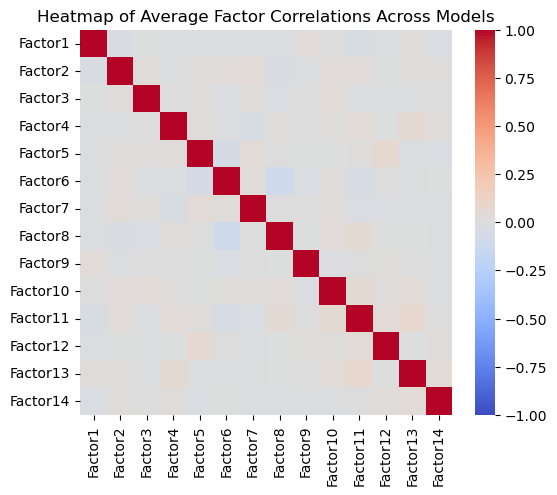

In [12]:
# List to store correlation matrices of each model
factor_corr = []

# Compute correlation matrix for factors from each model
for m in model_list:
    factors = m.get_factors(df=True)   # get factors as a DataFrame
    corr_matrix = factors.corr()       # compute correlation between factors
    factor_corr.append(corr_matrix)

# Compute the mean correlation matrix across all models
mean_corr_matrix = sum(factor_corr) / len(factor_corr)

# -----------------------------
# Plot heatmap of mean factor correlations
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(mean_corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Heatmap of Average Factor Correlations Across Models")
plt.show()

#### No significant correlations between factors

#### Heatmap showing the average correlation between factors and the one-hot vectors of each tumor subtype, calculated across 5 models.

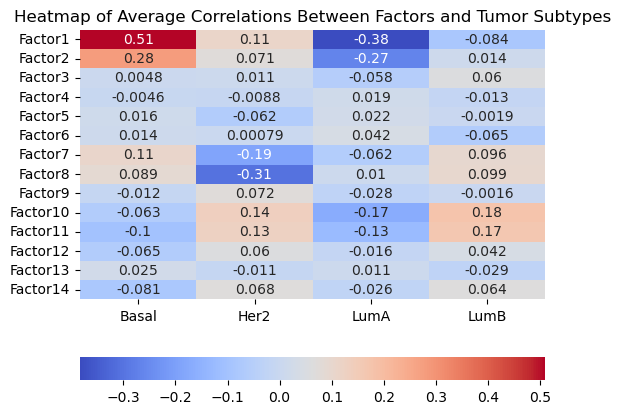

In [13]:

# List to store correlation matrices between factors and tumor subtype one-hot vectors
factor_subtype_corr = []

# Iterate over all models
for m in model_list:
    # Get factors as a DataFrame (rows = samples, columns = factors)
    factors = m.get_factors(df=True)
    
    # Align metadata with the factor indices
    meta = df_all_meta.loc[factors.index]
    
    # Select only the tumor subtype one-hot columns and convert to float
    meta = meta[['Basal', 'Her2', 'LumA', 'LumB']].astype(float)
    
    # Initialize an empty DataFrame to store correlations between factors and subtypes
    factor_subtype_corr_matrix = pd.DataFrame(index=factors.columns, columns=meta.columns)
    
    # Compute correlation between each factor and each subtype
    for factor in factors.columns:
        for subtype in meta.columns:
            factor_subtype_corr_matrix.loc[factor, subtype] = factors[factor].corr(meta[subtype])
    
    # Ensure all values are floats
    factor_subtype_corr_matrix = factor_subtype_corr_matrix.astype(float)
    
    # Append the correlation matrix of this model to the list
    factor_subtype_corr.append(factor_subtype_corr_matrix)
    
# Compute the mean correlation matrix across all models
mean_corr_matrix = sum(factor_subtype_corr) / len(factor_subtype_corr)

# -----------------------------
# Plot heatmap of mean correlations
# -----------------------------
vmin = mean_corr_matrix.min().min()  # global minimum for color scale
vmax = mean_corr_matrix.max().max()  # global maximum for color scale

plt.figure(figsize=(6,5))
sns.heatmap(mean_corr_matrix, annot=True, cmap='coolwarm', vmin=vmin, vmax=vmax,cbar_kws={"orientation": "horizontal"})
plt.title("Heatmap of Average Correlations Between Factors and Tumor Subtypes")
plt.show()


Factors 1 and 2 show a strong positive association with Basal and a negative association with LumA. Factors 7 and 8 show a strong negative association with Her2. Factors 10 and 11 show a negative association with LumA and a positive association with LumB. The other factors show practically no association. We select factors that have an absolute correlation of at least 0.1 with at least one tumor subtype.

### Variance explained by each factor for each view (mRNA, DNAm, RPPA). Values are averaged across 5 models.

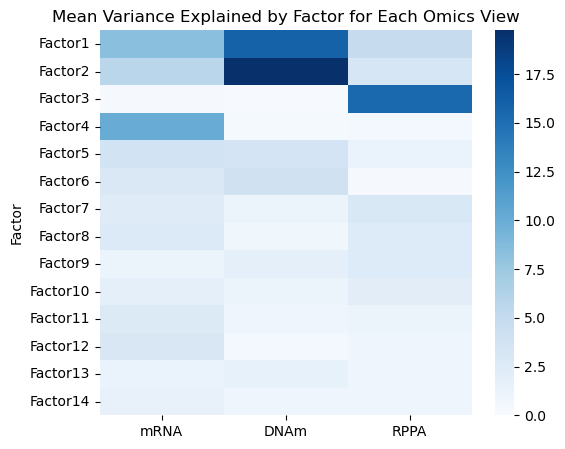

In [14]:

# List to store variance explained (R2) matrices for each model
model_var_expl = []

# Iterate over all trained models
for m in model_list:
    # Get R2 values (variance explained) for factors 0 to 13 (14 factors)
    var_expl = m.get_r2(factors=list(range(14)))
    
    # Set the index of the DataFrame to be the factor names
    var_expl.index = var_expl['Factor']
    
    # Subset variance explained for each view (omics)
    mRNA_var = var_expl.loc[var_expl['View'] == 'mRNA', ['R2']]
    DNAm_var = var_expl.loc[var_expl['View'] == 'DNAm', ['R2']]
    RPPA_var = var_expl.loc[var_expl['View'] == 'RPPA', ['R2']]
    
    # Concatenate the R2 columns for the three views into a single DataFrame
    var_expl = pd.concat([mRNA_var, DNAm_var, RPPA_var], axis=1)
    
    # Rename columns to match the omics views
    var_expl.columns = ['mRNA','DNAm','RPPA']
    
    # Append this model's variance explained DataFrame to the list
    model_var_expl.append(var_expl)
    
# Compute the mean variance explained across all models
mean_var_expl = sum(model_var_expl) / len(model_var_expl)    

# Define min and max values for heatmap color scale
vmin = 0
vmax = mean_var_expl.max().max()  # global maximum

# -----------------------------
# Plot heatmap of mean variance explained
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(mean_var_expl, annot=False, cmap="Blues", vmin=vmin, vmax=vmax)
plt.title("Mean Variance Explained by Factor for Each Omics View")
plt.show()


 Factors that mostly explain variance are the first 4 factors

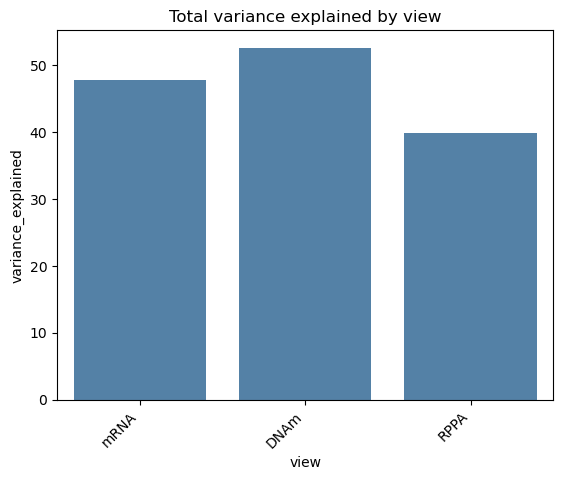

In [15]:

# Compute the sum of each column in the mean variance explained DataFrame
col_sums = mean_var_expl.sum().reset_index()

# Rename the columns for clarity
col_sums.columns = ["view", "variance_explained"]  # "colonne" = column name, "somme" = sum

# Create a bar plot showing the sum of variance explained per view
sns.barplot(data=col_sums, x="view", y="variance_explained", color="steelblue")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Set the title of the plot
plt.title("Total variance explained by view")

# Display the plot
plt.show()


### Train a logistic regression model on the features from each of the 5 MOFA models and assess model performance on the test set associated with each MOFA model.

In [16]:
 train_accuracies, train_f1_scores,train_reports,test_accuracies,test_f1_scores,test_reports,log_models = train_test_log_reg_on_MOFA(mRNA_exprs, DNAm_exprs, RPPA_exprs, model_list, df_all_meta)

In [17]:
print("Accuracy:", np.mean(test_accuracies))
print("Macro F1:", np.mean(test_f1_scores))
test_reports_sum = sum(test_reports) / len(test_reports)
print(test_reports_sum)
print('best model:', np.argmax(test_f1_scores))

Accuracy: 0.7174994216978949
Macro F1: 0.6990458079932328
              precision    recall  f1-score     support
Basal          1.000000  0.907609  0.950698   23.800000
Her2           0.575661  0.940000  0.702942    9.800000
LumA           0.796196  0.733078  0.759058   70.400000
LumB           0.344096  0.438095  0.383485   27.600000
accuracy       0.717499  0.717499  0.717499    0.717499
macro avg      0.678988  0.754696  0.699046  131.600000
weighted avg   0.721390  0.717499  0.710221  131.600000
best model: 4


### Construct dataframe that contains Accuracies, Macro F1 and F1 for each class of each fold/MOFA model

In [18]:
summary = construct_sumary_dataframe(test_accuracies,test_f1_scores,test_reports,'None','MOFA+logistic_regression')
summary

,0,1,2,3,4,mean,std,model,missing_value_imputation_method
Accuracy,0.674242,0.712121,0.651515,0.755725,0.793893,0.717499,0.058205,MOFA+logistic_regression,None
Macro F1,0.552730,0.728092,0.661546,0.756863,0.795997,0.699046,0.095395,MOFA+logistic_regression,None
Basal F1,0.909091,0.933333,0.954545,0.956522,1.000000,0.950698,0.033586,MOFA+logistic_regression,None
Her2 F1,0.540541,0.750000,0.714286,0.782609,0.727273,0.702942,0.094414,MOFA+logistic_regression,None
LumA F1,0.761290,0.744186,0.701493,0.788321,0.800000,0.759058,0.038963,MOFA+logistic_regression,None
LumB F1,0.000000,0.484848,0.275862,0.500000,0.656716,0.383485,0.253549,MOFA+logistic_regression,None


In [19]:
summary.to_csv("MOFA_results.csv", index=True)

### Interpretability of the best model over the k folds (selected by macro F1 score)

#### Factor 2 vs Factor 7 scatterplot for the best model shows that Basal, Luminal, and Her2 subtypes can be distinguished; however, LumA and LumB are not well separated.

In [27]:

m4.metadata['paper_BRCA_Subtype_PAM50'] = df_all_meta.loc[m4.metadata.index, 'paper_BRCA_Subtype_PAM50']


<Axes: title={'center': 'paper_BRCA_Subtype_PAM50'}, xlabel='Factor2', ylabel='Factor7'>

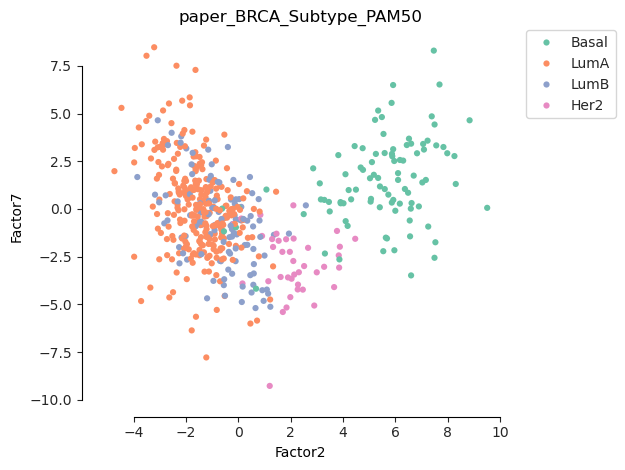

In [28]:
mfx.plot_factors_scatter(m4,x=1,y=6, color='paper_BRCA_Subtype_PAM50')

###  Heatmaps showing the top 10 most important features from each omic (in terms of weight values) for factors 1. The color indicates both the value and the sign of the weights, showing whether a feature is positively or negatively associated with a given factor.

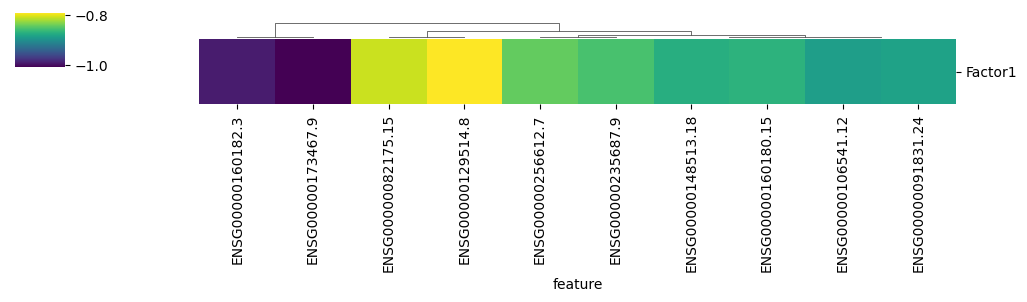

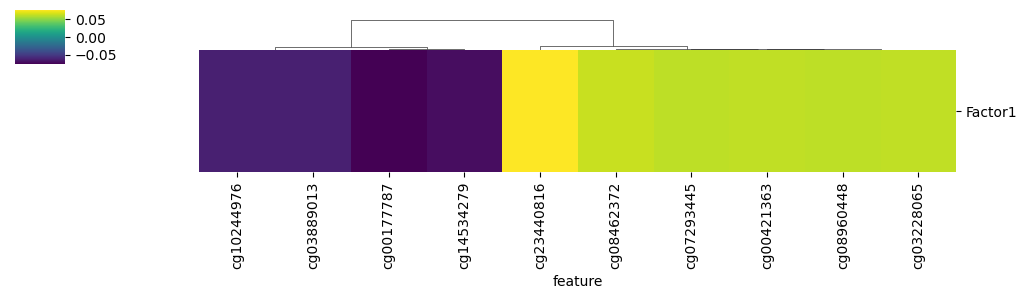

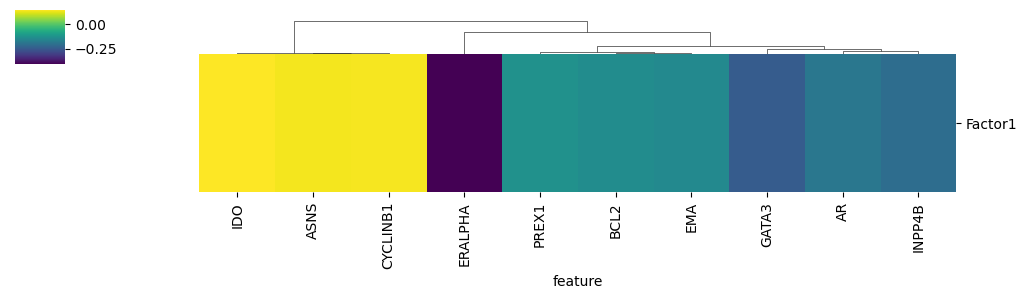

In [29]:
#mRNA
mfx.plot_weights_heatmap(m3, n_features=10,view = 'mRNA', 
                         factors= ['Factor1'], 
                         xticklabels_size=10, w_abs=False, 
                         cmap="viridis", cluster_factors=False,figsize=(10, 3))
#DNAm
mfx.plot_weights_heatmap(m3, n_features=10,view = 'DNAm', 
                         factors= ['Factor1'], 
                         xticklabels_size=10, w_abs=False, 
                         cmap="viridis", cluster_factors=False,figsize=(10, 3))
#RPPA
mfx.plot_weights_heatmap(m3, n_features=10,view = 'RPPA', 
                         factors= ['Factor1'], 
                         xticklabels_size=10, w_abs=False, 
                         cmap="viridis", cluster_factors=False,figsize=(10, 3))